script to calculate the coordinates of head position measured with DLC
excluded worms from june head position has more oordinates then center stage

In [1]:
#Importing the toolbox (takes several seconds)
import pandas as pd
from pathlib import Path
import numpy as np
import os
import matplotlib.pyplot as plt
import tifffile as tiff
from natsort import natsorted
import glob
import pylab

In [2]:
from headcast_functions import *

In [11]:
head2(data,px_mm,lenght)

array([0.27856273, 0.27996923, 0.28143187, ..., 0.18382991, 0.18326239,
       0.18312601])

In [20]:
type(5)

int

In [21]:
type(5.0)

float

In [2]:
##### function for calculating the distence of head from the center of the frame
def head(data, px_mm, lenght):
    """
    Convert this to that
    Parameters:
    -------------
    data, pandas dataframe
    lsdjasdlk
    px_mm, float
    length, int
    Returns:
    -------------
    """
    return(data*px_mm-lenght*px_mm/2)

In [5]:
path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_tracks/2020-07-01_17-01-27_chemotaxis_worm6-TablePosRecord.txt'
df_coords=pd.read_csv(path)

In [6]:
path_head='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/avi_all/2020-07-01_17-01-27_chemotaxis_worm6-channel-0-bigtiffDLC_resnet50_HeadTailAug10shuffle1_275000_filtered.h5'

In [7]:
df_coords_head_tail=pd.read_hdf(path_head, low_memory=False)

In [8]:
df_coords_head_tail

scorer    DLC_resnet50_HeadTailAug10shuffle1_275000                         \
bodyparts                                      Head                          
coords                                            x           y likelihood   
0                                        389.711609  210.913239   0.996472   
1                                        390.144379  210.976715   0.991877   
2                                        390.594421  210.976715   0.986385   
3                                        390.903259  211.140228   0.969252   
4                                        391.174713  211.142487   0.983928   
...                                             ...         ...        ...   
199996                                   360.581543  179.774857   0.998283   
199997                                   360.563049  179.774857   0.997769   
199998                                   360.563049  179.774857   0.998213   
199999                                   360.388428  179.774857   0.998692   
200000                                   360.346466  179.774857   0.998626   

scorer                                        
bodyparts        Tail                         
coords              x           y likelihood  
0          186.799408  451.260254   0.987140  
1          187.362625  451.527924   0.977224  
2          187.374374  451.623749   0.965021  
3          187.554306  451.848267   0.965582  
4          188.050034  451.918915   0.967007  
...               ...         ...        ...  
199996     325.068146  465.529633   0.994418  
199997     325.054749  465.529633   0.995057  
199998     325.054749  465.497864   0.995303  
199999     324.962982  465.497864   0.995747  
200000     324.734741  464.959076   0.995751  

[200001 rows x 6 columns]

getting the x and y coordinates for headposition, converting them into mm and insert them as collumns in the data frame with the x and y coordinates of the center  then calculate the distance between center point and head/tail position

In [9]:
px_mm=0.00325 # this value represents how much mm is one pixel

In [10]:
#for the head
scorer=df_coords_head_tail.columns.get_level_values(0)[0] # defines scorer as the first column of the dataframe
df_coords_head_tail_center=df_coords
data=df_coords_head_tail[scorer]['Head']['x'].values
lenght=608 #lenght of x axis in frame (measured with fiji)
df_coords_head_tail_center['xhead']= head(data,px_mm,lenght) #610--xlength of window in px
data=df_coords_head_tail[scorer]['Tail']['x'].values


NameError: name 'head' is not defined

In [85]:
# for the tail
df_coords_head_tail_center['xtail']= head(data,px_mm,lenght)
data=df_coords_head_tail[scorer]['Head']['y'].values
lenght=610 #lengh of y axis (measured with fiji)
df_coords_head_tail_center['yhead']=head(data,px_mm,lenght) #ylenght of window in px
data=df_coords_head_tail[scorer]['Tail']['y'].values
df_coords_head_tail_center['ytail']= head(data,px_mm,lenght)

In [86]:
df_coords_head_tail_center

,time,xc,x,yc,y,xhead,xtail,yhead,ytail
0,17:01:30.648,x,33.4918,y,9.3320,0.278563,-0.380902,-0.305782,0.475346
1,17:01:30.665,x,33.4918,y,9.3320,0.279969,-0.379071,-0.305576,0.476216
2,17:01:30.665,x,33.4918,y,9.3320,0.281432,-0.379033,-0.305576,0.476527
3,17:01:30.665,x,33.4918,y,9.3320,0.282436,-0.378449,-0.305044,0.477257
4,17:01:30.680,x,33.4911,y,9.3314,0.283318,-0.376837,-0.305037,0.477486
...,...,...,...,...,...,...,...,...,...
199996,17:21:30.657,x,9.0679,y,16.2026,0.183890,0.068471,-0.406982,0.521721
199997,17:21:30.673,x,9.0679,y,16.2025,0.183830,0.068428,-0.406982,0.521721
199998,17:21:30.673,x,9.0679,y,16.2024,0.183830,0.068428,-0.406982,0.521618
199999,17:21:30.689,x,9.0679,y,16.2021,0.183262,0.068130,-0.406982,0.521618


In [87]:
df_coords_head_tail_center.describe()

,x,y,xhead,xtail,yhead,ytail
count,200001.000000,200001.000000,200001.000000,200001.000000,200001.000000,200001.000000
mean,14.608979,14.511512,0.210981,-0.296374,0.059215,0.037650
std,7.263741,3.624141,0.225592,0.186257,0.363964,0.330366
min,8.752800,6.556000,-0.535654,-0.972687,-0.888046,-0.936589
25%,9.097000,10.656800,0.087562,-0.422366,-0.309407,-0.267088
50%,10.105400,16.356400,0.262928,-0.332601,0.119877,0.032504
75%,19.768100,16.535500,0.379641,-0.214763,0.399397,0.326967
max,33.491800,19.491300,0.782831,0.659320,0.826089,0.963458


subtracting distance of head position from center

In [88]:
#for head
df_coords_head_tail_center_corrected=df_coords_head_tail_center
df_coords_head_tail_center_corrected['x_head_corrected']=df_coords_head_tail_center['x'] - df_coords_head_tail_center['xhead'] 
df_coords_head_tail_center_corrected['y_head_corrected']=df_coords_head_tail_center['y'] - df_coords_head_tail_center['yhead']
#for tail
df_coords_head_tail_center_corrected['x_tail_corrected']=df_coords_head_tail_center['x'] - df_coords_head_tail_center['xtail'] 
df_coords_head_tail_center_corrected['y_tail_corrected']=df_coords_head_tail_center['y'] - df_coords_head_tail_center['ytail']
df_coords_head_tail_center_corrected

,time,xc,x,yc,y,xhead,xtail,yhead,ytail,x_head_corrected,y_head_corrected,x_tail_corrected,y_tail_corrected
0,17:01:30.648,x,33.4918,y,9.3320,0.278563,-0.380902,-0.305782,0.475346,33.213237,9.637782,33.872702,8.856654
1,17:01:30.665,x,33.4918,y,9.3320,0.279969,-0.379071,-0.305576,0.476216,33.211831,9.637576,33.870871,8.855784
2,17:01:30.665,x,33.4918,y,9.3320,0.281432,-0.379033,-0.305576,0.476527,33.210368,9.637576,33.870833,8.855473
3,17:01:30.665,x,33.4918,y,9.3320,0.282436,-0.378449,-0.305044,0.477257,33.209364,9.637044,33.870249,8.854743
4,17:01:30.680,x,33.4911,y,9.3314,0.283318,-0.376837,-0.305037,0.477486,33.207782,9.636437,33.867937,8.853914
...,...,...,...,...,...,...,...,...,...,...,...,...,...
199996,17:21:30.657,x,9.0679,y,16.2026,0.183890,0.068471,-0.406982,0.521721,8.884010,16.609582,8.999429,15.680879
199997,17:21:30.673,x,9.0679,y,16.2025,0.183830,0.068428,-0.406982,0.521721,8.884070,16.609482,8.999472,15.680779
199998,17:21:30.673,x,9.0679,y,16.2024,0.183830,0.068428,-0.406982,0.521618,8.884070,16.609382,8.999472,15.680782
199999,17:21:30.689,x,9.0679,y,16.2021,0.183262,0.068130,-0.406982,0.521618,8.884638,16.609082,8.999770,15.680482


In [14]:
df_coords_head_tail_center_corrected.describe()

,x,y,xhead,xtail,yhead,ytail,x_head_corrected,y_head_corrected,x_tail_corrected,y_tail_corrected
count,200001.000000,200001.000000,200001.000000,200001.000000,200001.000000,200001.000000,200001.000000,200001.000000,200001.000000,200001.000000
mean,14.608979,14.511512,0.210981,-0.296374,0.059215,0.037650,14.397998,14.452297,14.905353,14.473862
std,7.263741,3.624141,0.225592,0.186257,0.363964,0.330366,7.222188,3.660042,7.266248,3.616988
min,8.752800,6.556000,-0.535654,-0.972687,-0.888046,-0.936589,8.568329,6.312546,8.672719,6.352934
25%,9.097000,10.656800,0.087562,-0.422366,-0.309407,-0.267088,8.820934,10.518642,9.443120,10.892354
50%,10.105400,16.356400,0.262928,-0.332601,0.119877,0.032504,10.053832,16.306412,10.240119,16.030259
75%,19.768100,16.535500,0.379641,-0.214763,0.399397,0.326967,19.313229,16.758350,20.326570,16.596572
max,33.491800,19.491300,0.782831,0.659320,0.826089,0.963458,33.213237,19.556622,33.872702,19.939728


calculating concentration changes

In [89]:
def sigmoid(x, L ,x0, k, b):
    """
    Parameters:
    ---------------------------
    x: data
    L: The Max value of the sigmoid fit
    x0: midpoint of the function
    k: slope
    b:intercept
    """
    y = L / (1 + np.exp(-k*(x-x0)))+b
    return (y)

In [98]:
x_head=df_coords_head_tail_center_corrected['x_head_corrected'].values
print(x_head)
x_tail=df_coords_head_tail_center_corrected['x_tail_corrected'].values
print(x_tail)

[33.21323727 33.21183077 33.21036813 ...  8.88407009  8.88463761
  8.88477399]
[33.87270192 33.87087147 33.87083328 ...  8.99947207  8.99977031
  9.00051209]


In [102]:
#this is telling you the position of every x position occuring in the data
#parameters determined via the curve fit
L=1
x0=3.81953189
k=-0.69421567
b=0
y_fit_head=sigmoid(x_head, L, x0, k, b)
y_fit_tail=sigmoid(x_tail, L, x0, k, b)

In [111]:
#creating df with x head and tail position and concentration
position_concentration = pd.DataFrame(data=x_head,columns=["head_position"])
position_concentration['tail_posiiton']=pd.DataFrame(data=x_tail,columns=["tail_position"])
position_concentration['Concentration_head']=y_fit_head
position_concentration['Concentration_tail']=y_fit_tail
position_concentration

,head_position,tail_posiiton,Concentration_head,Concentration_tail
0,33.213237,33.872702,1.373957e-09,8.692576e-10
1,33.211831,33.870871,1.375299e-09,8.703629e-10
2,33.210368,33.870833,1.376696e-09,8.703860e-10
3,33.209364,33.870249,1.377656e-09,8.707394e-10
4,33.207782,33.867937,1.379170e-09,8.721376e-10
...,...,...,...,...
199996,8.884010,8.999429,2.886488e-02,2.670165e-02
199997,8.884070,8.999472,2.886371e-02,2.670086e-02
199998,8.884070,8.999472,2.886371e-02,2.670086e-02
199999,8.884638,8.999770,2.885267e-02,2.669548e-02


In [112]:
#calculate the concentration change
concentration_change=position_concentration
concentration_change

,head_position,tail_posiiton,Concentration_head,Concentration_tail
0,33.213237,33.872702,1.373957e-09,8.692576e-10
1,33.211831,33.870871,1.375299e-09,8.703629e-10
2,33.210368,33.870833,1.376696e-09,8.703860e-10
3,33.209364,33.870249,1.377656e-09,8.707394e-10
4,33.207782,33.867937,1.379170e-09,8.721376e-10
...,...,...,...,...
199996,8.884010,8.999429,2.886488e-02,2.670165e-02
199997,8.884070,8.999472,2.886371e-02,2.670086e-02
199998,8.884070,8.999472,2.886371e-02,2.670086e-02
199999,8.884638,8.999770,2.885267e-02,2.669548e-02


In [113]:
#calculating concentration change
concentration_change=position_concentration
concentration_change
concentration_change["Concentration_change_head"] = position_concentration["Concentration_head"].diff()
concentration_change["Concentration_change_tail"] = position_concentration["Concentration_tail"].diff()
concentration_change

,head_position,tail_posiiton,Concentration_head,Concentration_tail,Concentration_change_head,Concentration_change_tail
0,33.213237,33.872702,1.373957e-09,8.692576e-10,NaN,NaN
1,33.211831,33.870871,1.375299e-09,8.703629e-10,1.342208e-12,1.105295e-12
2,33.210368,33.870833,1.376696e-09,8.703860e-10,1.397170e-12,2.307250e-14
3,33.209364,33.870249,1.377656e-09,8.707394e-10,9.596168e-13,3.534153e-13
4,33.207782,33.867937,1.379170e-09,8.721376e-10,1.514056e-12,1.398146e-12
...,...,...,...,...,...,...
199996,8.884010,8.999429,2.886488e-02,2.670165e-02,0.000000e+00,0.000000e+00
199997,8.884070,8.999472,2.886371e-02,2.670086e-02,-1.169611e-06,-7.855434e-07
199998,8.884070,8.999472,2.886371e-02,2.670086e-02,0.000000e+00,0.000000e+00
199999,8.884638,8.999770,2.885267e-02,2.669548e-02,-1.104148e-05,-5.380100e-06


In [114]:
concentration_change.describe()

,head_position,tail_posiiton,Concentration_head,Concentration_tail,Concentration_change_head,Concentration_change_tail
count,200001.000000,200001.000000,2.000010e+05,2.000010e+05,2.000000e+05,2.000000e+05
mean,14.397998,14.905353,1.469965e-02,1.049772e-02,1.442501e-07,1.334105e-07
std,7.222188,7.266248,1.379917e-02,9.798728e-03,3.193689e-04,2.078878e-05
min,8.568329,8.672719,1.373957e-09,8.692576e-10,-1.634261e-02,-6.264798e-03
25%,8.820934,9.443120,2.131737e-05,1.054926e-05,-5.372938e-07,-1.048007e-09
50%,10.053832,10.240119,1.302275e-02,1.146107e-02,2.638635e-11,3.301816e-11
75%,19.313229,20.326570,3.011800e-02,1.976299e-02,1.063545e-06,5.035912e-07
max,33.213237,33.872702,3.568494e-02,3.327336e-02,1.644746e-02,6.354017e-03


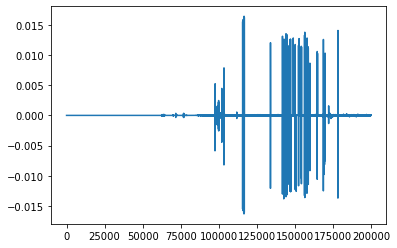

In [118]:
#plot concentration change over time
y_head=concentration_change['Concentration_change_head']
y_tail=concentration_change['Concentration_change_tail']
x = np.arange(200001)
pylab.plot(x,y_head)
#pylab.xlim(8, 12)
pylab.show()

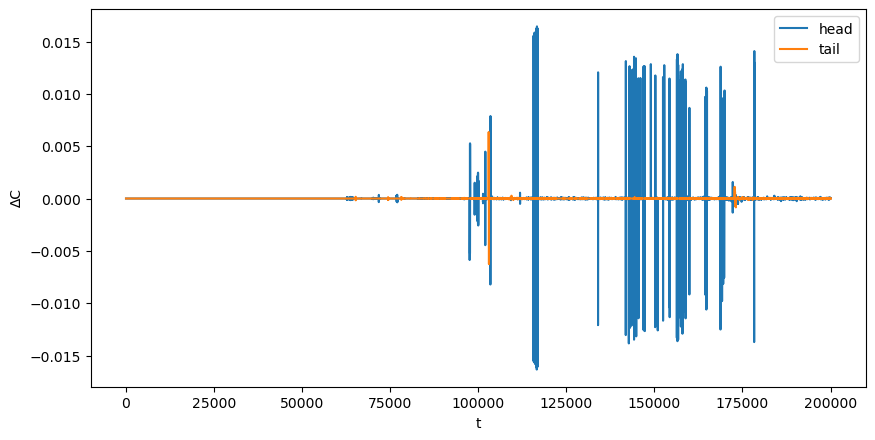

In [129]:
fig3, ax3 = plt.subplots(1,1, figsize = (10,5), dpi=100)
ax3.plot(x,y_head,label="head")
ax3.plot(x,y_tail,label="tail")
ax3.legend()
plt.xlabel("t")
plt.ylabel("∆C")

Annotations